 # ----------------  TALLER 1: CLASIFICACIÓN - DIAGNÓSTICO DE ENFERMEDAD TIROIDEA ----------------


 # FASE 1 - EDA, LIMPIEZA Y PROCESAMIENTO


## 1. Análisis del dataset
El dataset cuenta con información recopilada de varios pacientes con cáncer de tiroides, donde se tiene información de diferentes características tanto clinicas como patológicas (ej. edad, historial de tabaquismo/radioterapia, tamaño y etapa del tumor, tipo de patologia, respuesta al tratamiento, entre otras). El target es la columa de **"Recurred"**, la cuál muestra si después del tratamiento la persona volvió a padecer de cancer. Considerando esto, el dataset nos permite entrenar un modelo de ML donde permita prever si un paciente tiene posibilidad de volver a desarrollar cancer, analizando información de su perfil clínico. 

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import RandomizedSearchCV




## 2.  Cargue del Dataset

Se adjunta la base de datos descargada del repositorio como .csv y adjunta en la carpeta de "data". Para el cargue de la data, se usa la libreria de pandas. Luego del cargue de los datos, se muestran características del dataset como head(), tail(), .shape y .info()

In [87]:
df = pd.read_csv("data/Thyroid_Diff.csv")


print("Dataset de Thyroid Disease cargado exitosamente.")
print("A. head() ---> mostrando las primeras 5 filas del dataset")
display(df.head())
print("B. tail() ---> mostrando las últimas 5 filas del dataset")
display(df.tail())
print("C. shape ---> mostrando las dimensiones del dataset")
print(df.shape)
print("D. info() ---> mostrando información sobre el dataset y sus tipos de datos que nos permitiran definir las primeras acciones del EDA y la preparación de los datos")
df.info()

Dataset de Thyroid Disease cargado exitosamente.
A. head() ---> mostrando las primeras 5 filas del dataset


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


B. tail() ---> mostrando las últimas 5 filas del dataset


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


C. shape ---> mostrando las dimensiones del dataset
(383, 17)
D. info() ---> mostrando información sobre el dataset y sus tipos de datos que nos permitiran definir las primeras acciones del EDA y la preparación de los datos
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    st

## 3. 'describe()' para columnas numéricas

In [88]:
display(df.describe())


,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


Para este dataset sólo se tiene una columna numérica, que es la de edad. 

**De los datos se puede observar lo siguiente**

**Media**= 40 años 
**Mediana(50%)**= 37 años
**Desviación estándard** = 15.13 años 
**Rango de edad** = Entre 15 y 82 años

Si analizamos los valores de media y mediana, encontramos que la media es mayor a la mediana, lo que muestra que hay distribución de datos de edad con cola hacia la derecha, que puede estar ligado a mayor cantidad de pacientes de mayor edad. Adicional, según el rango de edad tenemos que los pacientes de edad máxima son de 82 años, lo que no ayuda a compensar con la edad de los pacientes más jóvenes. 

## 4. Valores Nulos por columna

In [89]:
nulls = df.isnull().sum()
percent = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({'n_nulos': nulls, 'percent_nulos': percent})
display(null_report)


,n_nulos,percent_nulos
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


**Resultado =>** No se encuentra ningún valor nulo en el dataset, por tanto no es necesario realizar ningún tipo de imputación, ni eliminar ninguna fila. Esto ya se había observado de igual manera en el punto 1. D. al ejecutar la función .info()

## 5. Datos duplicados

In [90]:
n_dup = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {n_dup}")
display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(19))

Filas duplicadas encontradas: 19


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
136,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
168,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
161,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
196,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
106,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
121,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
138,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
183,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
119,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
123,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No


In [91]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Se eliminaron {n_dup} filas, quedando un total de {df.shape[0]} filas")

Se eliminaron 19 filas, quedando un total de 364 filas


## 6. Revisión de inconsistencia en formato

In [92]:
cat_column = df.select_dtypes(include='str').columns.tolist()


for col in df.select_dtypes(include='str').columns:
    valores = sorted(df[col].unique().tolist())
    print(f"{col:22s} ({len(valores)} categorías): {valores}")



Gender                 (2 categorías): ['F', 'M']
Smoking                (2 categorías): ['No', 'Yes']
Hx Smoking             (2 categorías): ['No', 'Yes']
Hx Radiothreapy        (2 categorías): ['No', 'Yes']
Thyroid Function       (5 categorías): ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
Physical Examination   (5 categorías): ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
Adenopathy             (6 categorías): ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
Pathology              (4 categorías): ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']
Focality               (2 categorías): ['Multi-Focal', 'Uni-Focal']
Risk                   (3 categorías): ['High', 'Intermediate', 'Low']
T                      (7 categorías): ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
N                      (3 categorías): [

No se encuentran categorias repetidas por inconsistencia de formato. En general, se encuentra letras mayúsculas y espacios en blanco, que se procede a corregir. Para el cambio de mayúsculas a minúsculas se manejó exclusiones en cierto tipo de datos donde hay notaciones que por lectura creemos que es mejor mantenerlas en mayúscula 

In [93]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
cat_column = df.select_dtypes(include='str').columns.tolist()

excl_minuscula = ['t', 'n', 'm', 'stage']  # Columna a excluir de la conversión a minúsculas, pues dentro estas columnas hay datos con notación específica de mayúsculas, que sería mejor no cambiar


for col in cat_column:
    df[col] = df[col].astype(str).str.strip()

    if col not in excl_minuscula:
        df[col] = df[col].str.lower().str.replace(' ', '_')
    else:
        df[col] = df[col].str.replace(' ', '')

    

print("Tipos de datos actuales:\n",df.dtypes)
display(df.head())
        

Tipos de datos actuales:
 age                     int64
gender                    str
smoking                   str
hx_smoking                str
hx_radiothreapy           str
thyroid_function          str
physical_examination      str
adenopathy                str
pathology                 str
focality                  str
risk                      str
t                         str
n                         str
m                         str
stage                     str
response                  str
recurred                  str
dtype: object


,age,gender,smoking,hx_smoking,hx_radiothreapy,thyroid_function,physical_examination,adenopathy,pathology,focality,risk,t,n,m,stage,response,recurred
0,27,f,no,no,no,euthyroid,single_nodular_goiter-left,no,micropapillary,uni-focal,low,T1a,N0,M0,I,indeterminate,no
1,34,f,no,yes,no,euthyroid,multinodular_goiter,no,micropapillary,uni-focal,low,T1a,N0,M0,I,excellent,no
2,30,f,no,no,no,euthyroid,single_nodular_goiter-right,no,micropapillary,uni-focal,low,T1a,N0,M0,I,excellent,no
3,62,f,no,no,no,euthyroid,single_nodular_goiter-right,no,micropapillary,uni-focal,low,T1a,N0,M0,I,excellent,no
4,62,f,no,no,no,euthyroid,multinodular_goiter,no,micropapillary,multi-focal,low,T1a,N0,M0,I,excellent,no


## 7. Identificación de outliers

Sólo tenemos una columna con datos numéricos 'age', a la cual aplicamos IQR

In [94]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers = df[(df['age'] < lim_inf) | (df['age'] > lim_sup)]
print(f"\nOutliers detectados en la columna 'age': {outliers.shape[0]}")
print(f"Límite inferior {lim_inf}")
print(f"Límite superior {lim_sup}")




Outliers detectados en la columna 'age': 0
Límite inferior -3.0
Límite superior 85.0


No se identifican outliers en la columna de edad. Además, el modelo en general es de clasificación, por lo cual no se ve necesario hacer ningún tipo de trato sobre los datos, ni menos eliminarlos. 

## 8. Gráficas del EDA

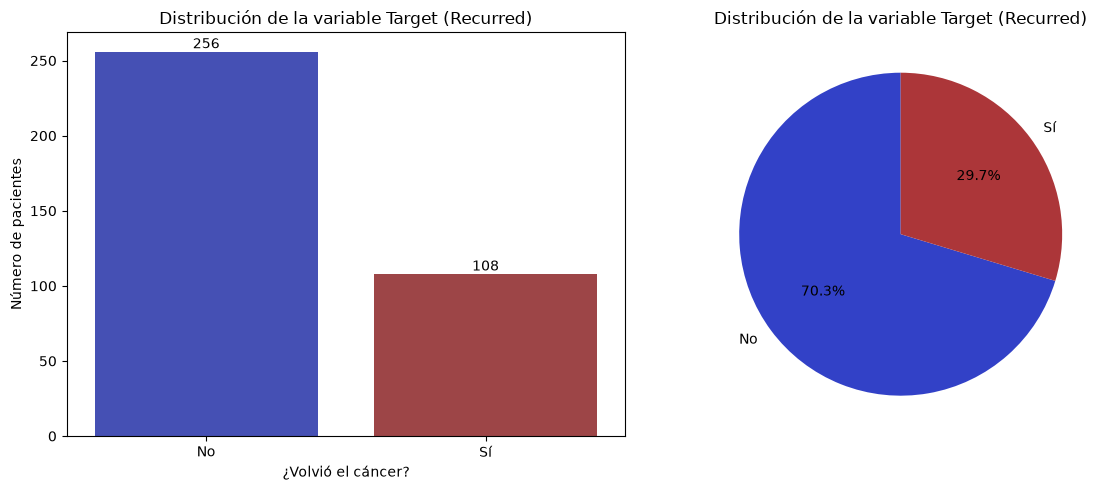

In [95]:
color = ["#3241C7", "#AC3639"]


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

#diagráma de barras para la distribución de la variable Target

sns.countplot(data=df, x='recurred', hue='recurred', legend=False, order=['no','yes'], palette=color , ax=ax[0])

ax[0].set_title('Distribución de la variable Target (Recurred)')
ax[0].set_xlabel('¿Volvió el cáncer?')
ax[0].set_ylabel('Número de pacientes')
ax[0].set_xticks(['no', 'yes'])
ax[0].set_xticklabels(['No', 'Sí'])
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),ha='center', va='bottom')


#gráfico de pastel para la distribución de la variable Target
conteo = df['recurred'].value_counts().sort_index()
ax[1].pie(conteo, labels=['No', 'Sí'], autopct='%1.1f%%', startangle=90, colors=color)
ax[1].set_title('Distribución de la variable Target (Recurred)')

plt.tight_layout()
plt.show()

De 364 pacientes, 265 (70.3%) **No** presentaron recurrencia y 108 (29.7%) **Sí**. Hay un **desbalance de clases moderado** (aprox. 2.4:1). Como responsable de la toma de decisiones, esto indica dos cosas: (1) el accuracy por sí solo será una métrica engañosa... pues un modelo que siempre prediga "No" ya acertaría ~70% de las veces sin aportar valor clínico; y. (2) conviene monitorear especialmente el *recall* de la clase "Yes", porque es la clase minoritaria y la que más importa detectar correctamente desde el punto de vista del ejercicio siendo la recurrencia el Target.

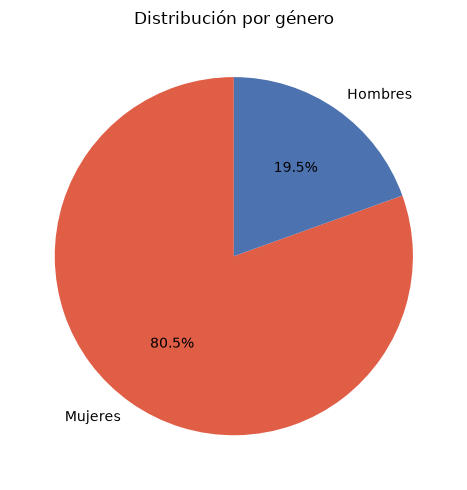

gender
f    293
m     71
Name: count, dtype: int64


In [96]:
#gráfica de pastel para la distribución por género
etiquetas = ['Mujeres', 'Hombres']
color = ["#E05D46", '#4C72B0']
fig, ax = plt.subplots(figsize=(5, 5))
cont_genero = df['gender'].value_counts()
ax.pie(cont_genero.values, labels=etiquetas, autopct='%1.1f%%', colors=color, startangle=90)
ax.set_title('Distribución por género')
plt.tight_layout()
plt.show()
print(cont_genero)

En la gráfica se puede observar que en un porcentaje mayor (80%), las mujeres padecen de enfermedades tiroideas y cáncer, y un menor porcentaje los hombres (19%). Este dato de distribución por género será importante para el entrenamiento del modelo, con un desafio en particular con la cantidad de hombres que al ser menor tendrá menor cantidad de ejemplos para ser más preciso en la predicción.  

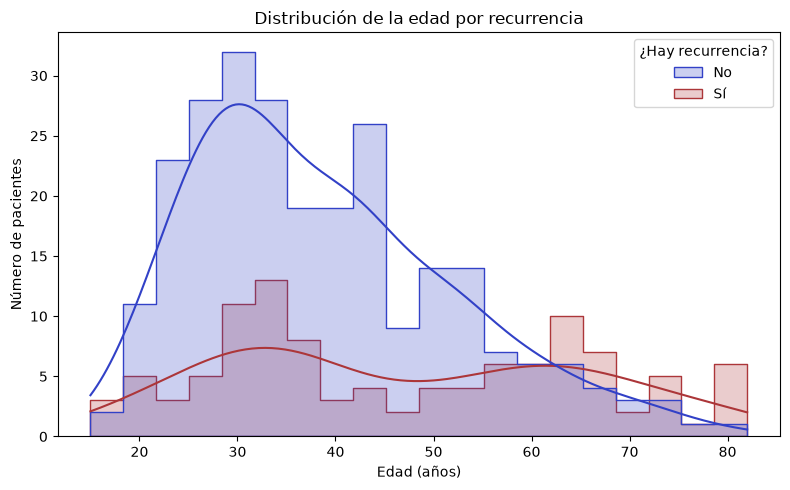

,count,mean,std,min,25%,50%,75%,max
recurred,,,,,,,,
no,256.0,38.777344,13.158507,17.0,28.75,36.0,46.25,81.0
yes,108.0,47.111111,18.267654,15.0,31.75,44.5,62.00,82.0


In [97]:
#histograma para ver la distribución de la edad por recurrencia
color = ["#3241C7", "#AC3639"]
fig, axes = plt.subplots(figsize=(8, 5))

sns.histplot(data=df, x='age', hue=df['recurred'].astype(object).replace({'no': 'No', 'yes': 'Sí'}).rename('¿Hay recurrencia?'), bins=20, kde=True, ax=axes, palette=color, element='step')
axes.set_title('Distribución de la edad por recurrencia')
axes.set_xlabel('Edad (años)')
axes.set_ylabel('Número de pacientes')

plt.tight_layout()
plt.show()

display(df.groupby('recurred')['age'].describe())

Este diagrama nos muestra que hay una menor tendencia de tener recurrencia de cáncer en personas más jóvenes. Aunque la cantidad de personas con recurrencia es de alguna manera estable entre los 20 y 70 años, se hace el comparativo respecto a la cantidad total de pacientes, y se relaciona con los que No tuvieron recurrencia. Además, se puede observar que despúes de aprox los 62 años, hay un cambio en la tendencia de recurrencia, marcandose el Sí con mayor conteo respecto al No, lo que sugiere que la edad un relevante en el estudio, y por lo cual se debe considerar en el entrenamiento. 

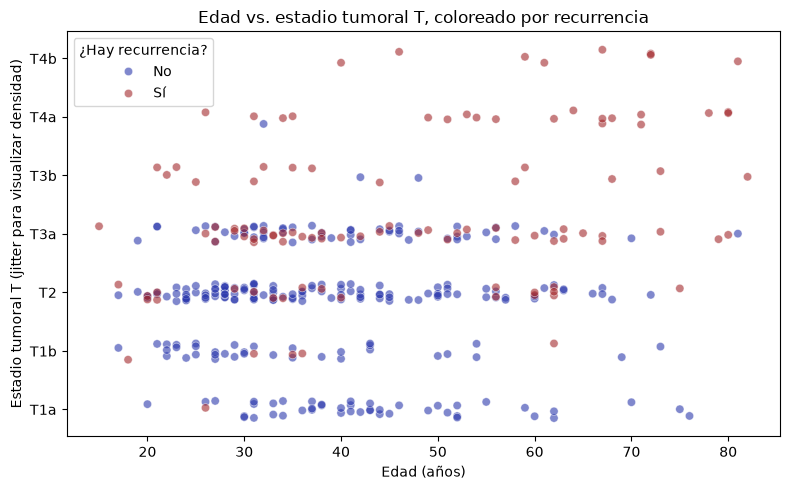

In [98]:
#Scatter plot

color = ["#2C39AD", "#A3282C"]
fig, ax = plt.subplots(figsize=(8, 5))
orden_lista_t = ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
df['t_jitter'] = df['t'].map({v: i for i, v in enumerate(orden_lista_t)}) + np.random.uniform(-0.15, 0.15, len(df))
sns.scatterplot(data=df, x='age', y='t_jitter', hue=df['recurred'].astype(object).replace({'no': 'No', 'yes': 'Sí'}).rename('¿Hay recurrencia?'), palette=color,alpha=0.6, ax=ax)
ax.set_yticks(range(len(orden_lista_t)))
ax.set_yticklabels(orden_lista_t)
ax.set_ylabel('Estadio tumoral T (jitter para visualizar densidad)')
ax.set_xlabel('Edad (años)')
ax.set_title('Edad vs. estadio tumoral T, coloreado por recurrencia')
plt.tight_layout()
plt.show()
df = df.drop(columns=['t_jitter'])

En este diagrama tenemos una relación de edad, etapa del tumor (Estadio tumoral) y la recurrencia. De este se puede deducir que a mayor estadio del tumor, mayor probabilñidad de recurrencia, al igual que a mayor edad. Por tanto, esto resalta la importancia de considerar múltiples variables en el entrenamiento y estudio, puesto que vemos cómo se correlacionan diferentes condiciones de los pacientes y cómo influyen en el Target. 

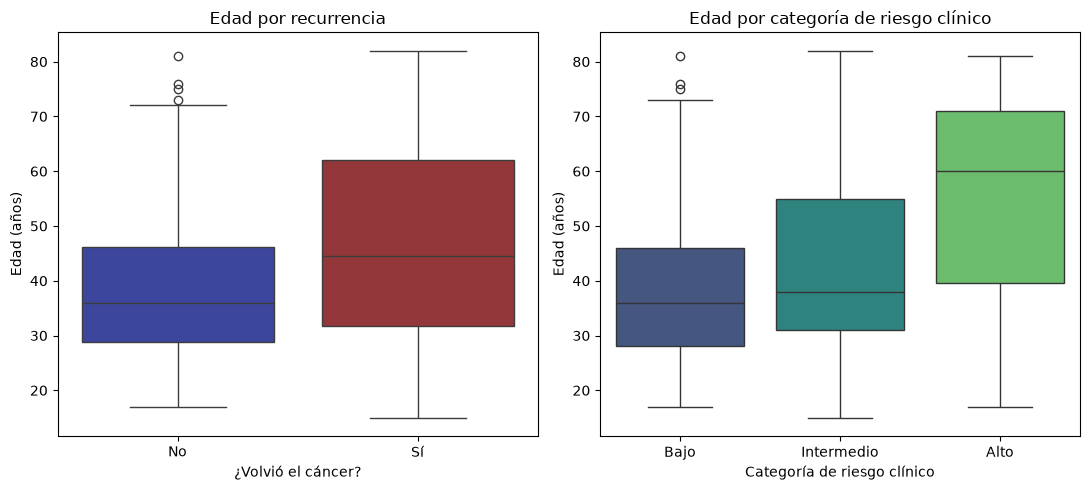

In [99]:
#boxplot

color = ["#2C39AD", "#A3282C"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(data=df, x='recurred', y='age', order=['no', 'yes'], hue = 'recurred', legend=False, palette=color, ax=axes[0])
axes[0].set_title('Edad por recurrencia')
axes[0].set_xlabel('¿Volvió el cáncer?')
axes[0].set_ylabel('Edad (años)')
axes[0].set_xticks(['no', 'yes'])
axes[0].set_xticklabels(['No', 'Sí'])

sns.boxplot(data=df, x='risk', y='age', order=['low', 'intermediate', 'high'], hue = 'risk', legend=False, palette='viridis', ax=axes[1])
axes[1].set_title('Edad por categoría de riesgo clínico')
axes[1].set_xlabel('Categoría de riesgo clínico')
axes[1].set_ylabel('Edad (años)')
axes[1].set_xticks(['low', 'intermediate', 'high'])
axes[1].set_xticklabels(['Bajo', 'Intermedio', 'Alto'])
plt.tight_layout()
plt.show()


Ambas graficas nos refuerzan lo que hemos venido observando en las anteriores, donde a mayor edad hay mayor riesgo de recurrencia, y a la vez considerando la nueva variable graficada, de riesgo clínico. Con lo cual, para el modelo será importante considerar todos o la mayoria de los tipos de datos en el dataset. 

## 9. Técnicas de codificación

1. **Variable Target (recurred):** Se mapeo de forma **binaria**, pues tiene apenas dos categorias que se podrían denominar como 0 y 1. 
2. **Variables con dos categorias de datos y sin un orden de importancia (gender, smoking, hx smoking, hx radiothreapy, focality, m, thyroid function, physical exam, adenopathy, pathology, response):** Dentro de estas variables, a excepción de 'response', todas tienes apenas dos categorias de datos, con lo cual se las puede denominar binarias (con 0 y 1); se ubica 'response' aquí porque si bien tiene más de dos categorias no hay un orden de importancia o escalabilidad. Esto nos permite **One-Hot Encoding**, y podemos usar drop=if_binary para los procesos de transformación. 
3. **Variables que tienes más de dos categorias y que denotan un orden de severidad (risk, t n, stage):** Para estas variables se considera **Ordinal Encoding**, debido a que sus datos demuestran orden y escalabilidad. En este caso es necesario este abordaje, para que KNN y regresión logística pueda intepretar correctamente los datos (por ejemplo, que en stage, IVB es más severo que II o I)



## 10. ¿Es necesario escalar?

En un inicio, no es necesario escalar las variables numéricas, que en este caso solo tenemos a la variable de edad 'age', pues en la evaluación de outliers en esta variable no se detectó ningún outlier, lo que no hay valores extremadamente altos y/o bajos que nos alteren el modelo. 

Pero, hay que tener en cuenta que, hay varias variables binarias, para lo cual se hace necesario que la variable 'age' se regularice con un regulizador estándar **(StandardScaler)**, para que los datos de edad no sesguem el modelo hacia esta variable. 

# FASE 2 - DIVISIÓN DE DATOS Y PIPELINE

## 11. Divión de datos para Train - Validation - Test

Es importante la división de los datos en las 3 categorias para tener un punto adicional de evaluación y no terminar sobreajustando los hiperparámetros del conjunto del test. Aquí, un punto a tener en cuenta, es que todo este proceso se debe hacer antes de continuar con cualquier tratamiento adicional de los datos, como codificación y/o escalación, pues es necesario tener un conjunto de test aislado, y así al final no tener un modelo sesgado. 

Para el presente taller, se considera una proporción 70/15/15

**Train--->** Esta porción de datos se usa de forma exclusiva para el entrenamiento del modelo, permitiendo que los algoritmos aprendan del comportamiento de todos estos datos. 

**Validation--->** Esta porción de datos permite hacer evaluaciones del modelo en las diferentes iteraciones de entrenamiento, permitiendo ajustar los hiperparámetros o tomar alguna decisión en el diseño del modelo antes de pasar a pruebas. 

**Test--->** Esta porción de datos se mantiene aislada hasta que se finalice el entrenamiento y validación, pues nos será de ayuda para evaluar el rendimiento del modelo 

In [100]:
# antes de la división de los datos, es importante separar la variable objetivo (target) de las características para poder realizar la división en conjuntos de entrenamiento, validación y prueba, pues si mantenemos el target el modelo queda sesgado.
    
X = df.drop('recurred', axis=1)
y = df['recurred'].map({'no': 0, 'yes': 1})  # Convertimos la variable objetivo a valores binarios (0 y 1) para facilitar el entrenamiento del modelo

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"{X_train.shape[0]} muestras de entrenamiento (Train)")
print(f"{X_val.shape[0]} muestras de validación (Validation)")
print(f"{X_test.shape[0]} muestras de prueba (Test)")






254 muestras de entrenamiento (Train)
55 muestras de validación (Validation)
55 muestras de prueba (Test)


## 12. Construcción de Pipeline

In [101]:
# Definición del grupo de columnas según su tipo de dato y la estrategia de preprocesamiento a aplicar

num_column = ['age']
nom_column = ['gender', 'smoking', 'hx_smoking', 'hx_radiothreapy', 'focality', 'm', 'thyroid_function', 'physical_examination', 'adenopathy', 'pathology', 'response']
#nom_cat= [['F', 'M'], ['no', 'yes'], ['no', 'yes'], ['no', 'yes'],['uni-focal', 'multi-focal'], ['M0', 'M1'], ['excellent', 'indeterminate', 'biochemical_incomplete', 'structural_incomplete']]
ord_column = ['risk', 't', 'n', 'stage']
ord_cat = [['low', 'intermediate', 'high'], ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'], ['N0', 'N1a', 'N1b'], ['I', 'II', 'III', 'IVA', 'IVB']]


# Ahora se cre el preprocesador que aplicará las transformaciones a cada tipo de columna según lo definido anteriormente. Se utiliza ColumnTransformer para aplicar diferentes pipelines a diferentes columnas del dataset.

preproc = ColumnTransformer(
    transformers=[ 
        ('num', StandardScaler(), num_column),
        ('nom', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), nom_column),
        ('ord', OrdinalEncoder(categories=ord_cat), ord_column),
    ]
)

X_train_preproc = preproc.fit_transform(X_train)
X_val_preproc = preproc.transform(X_val)
X_test_preproc = preproc.transform(X_test)

print(f"Dimensiones originales de X_train: {X_train.shape}")
print(f"Dimensiones de X_train transformado: {X_train_preproc.shape}")

Dimensiones originales de X_train: (254, 16)
Dimensiones de X_train transformado: (254, 35)


## 13. Verificación de data leakage

Como se puede observar en las últimas líneas del codigo anterior, la función .fit_transform sólo se aplica a los datos de 'X_train', mientras que a los de 'X_val' y 'X_test' solo se aplica la trasformación con .transform. Esto nos asegura que el aprendizaje generado por la transormación de los datos aplicados se aplique solo a los datos de entrenamiento, y con esto, se evita el data leakage (fuga de datos). 



# FASE 3 - MODELADO DE CLASIFICACIÓN

## 16 - 17. Entrenamiento Y predicción

### KNN Classifier - LogisticRegression

In [102]:

knn = KNeighborsClassifier(n_neighbors=5)
log_l2 = LogisticRegression(C=1.0, max_iter=2000, random_state=45)
log_l1 = LogisticRegression(solver='liblinear', C=1.0, max_iter=2000, random_state=45)

models = {
    'KNN': knn,
    'LogReg_L2': log_l2,
    'LogReg_L1': log_l1,
}
predict = {}

for name, model in models.items():
    model.fit(X_train_preproc, y_train)
    y_pred_train = model.predict(X_train_preproc)
    y_pred_val = model.predict(X_val_preproc)
    
    predict[name] = {'train': y_pred_train, 'val': y_pred_val}
    print(f"Modelo '{name}' entrenado exitosamente.")

Modelo 'KNN' entrenado exitosamente.
Modelo 'LogReg_L2' entrenado exitosamente.
Modelo 'LogReg_L1' entrenado exitosamente.


# FASE 4 - MÉTRICAS EN TRAIN Y VALIDACIÓN: DETECCIÓN DE OVERFITTING/UNDERFITTING

## 19. Cálculo de Accuracy, Precision, Recall, F1-Score, matriz de confusión


In [103]:
# Calculo de métricas de evaluación para cada modelo en los conjuntos de entrenamiento y validación
def evaluate_model(y_true, y_pred, model_name):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

result_metricas = []

for name in models:
    metricas_train = evaluate_model(y_train, predict[name]['train'], name)
    metricas_val = evaluate_model(y_val, predict[name]['val'], name)
    result_metricas.append({'Modelo': name, 'Conjunto': 'Train', **metricas_train})
    result_metricas.append({'Modelo': name, 'Conjunto': 'Validation', **metricas_val})

metrics_df = pd.DataFrame(result_metricas).set_index(['Modelo', 'Conjunto']).round(3)
display(metrics_df)


Accuracy  Precision  Recall  F1-Score
Modelo    Conjunto                                         
KNN       Train          0.941      0.969   0.827     0.892
          Validation     0.855      0.846   0.647     0.733
LogReg_L2 Train          0.972      0.986   0.920     0.952
          Validation     0.982      1.000   0.941     0.970
LogReg_L1 Train          0.969      0.972   0.920     0.945
          Validation     0.964      0.941   0.941     0.941

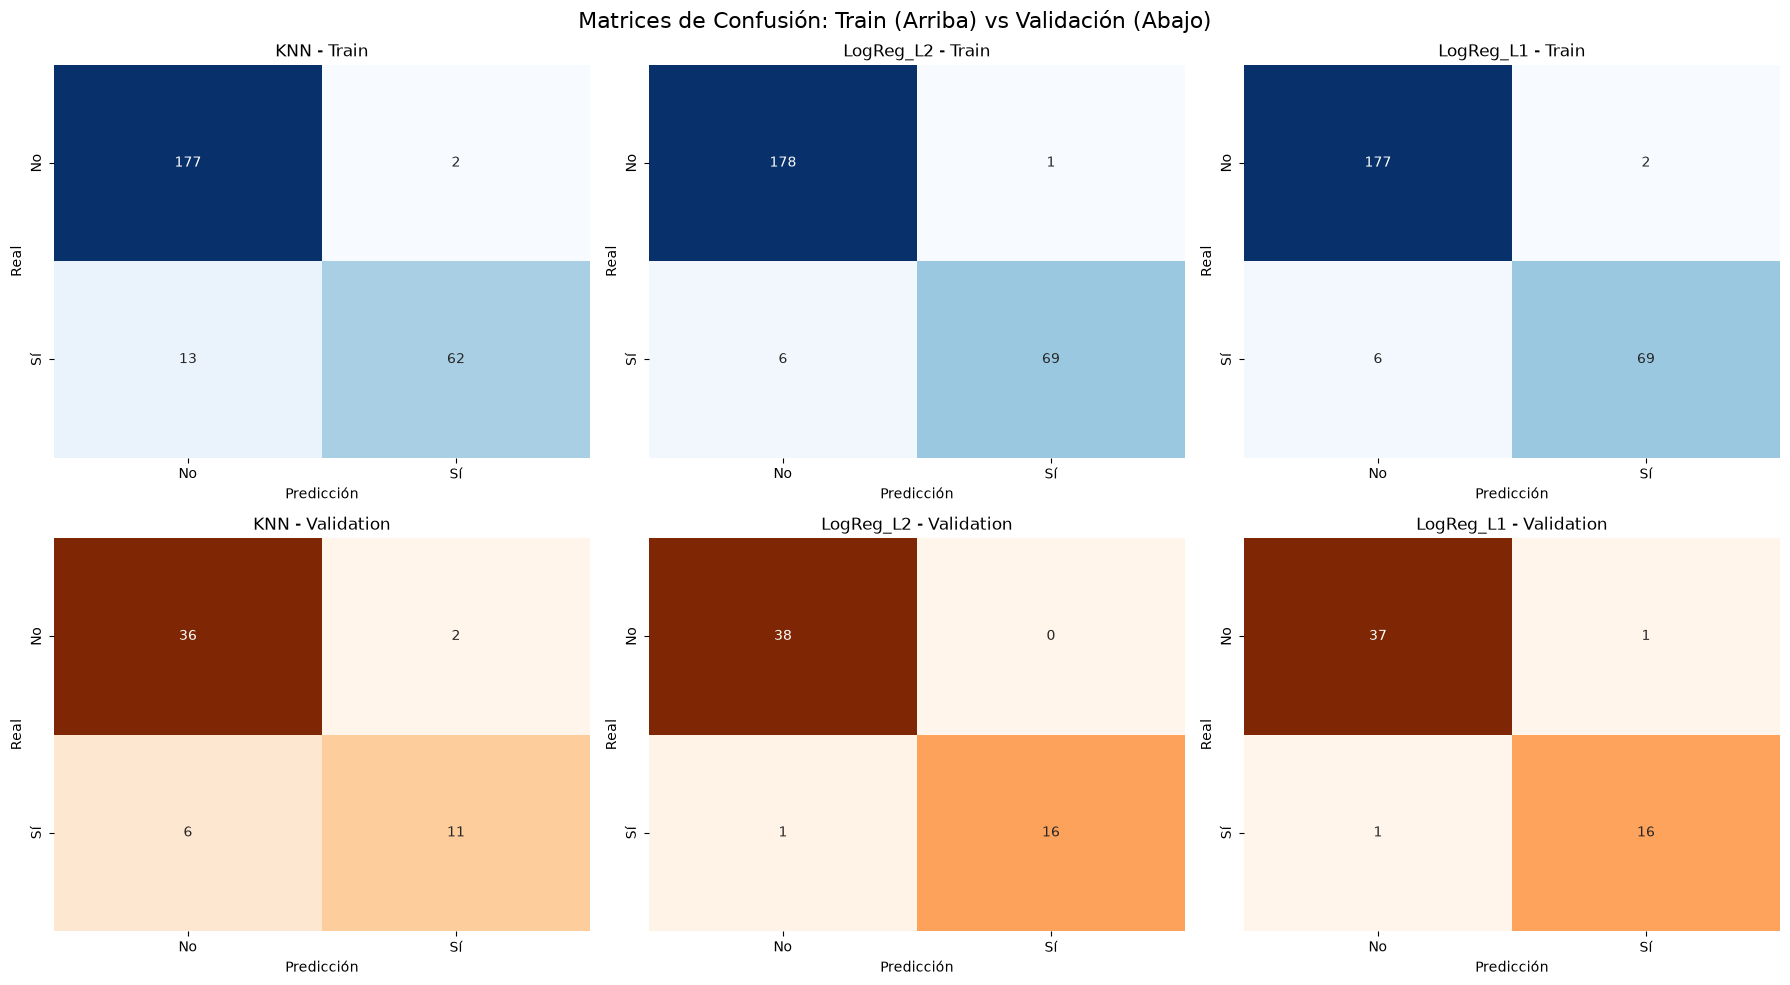

In [104]:
# Matriz de confusión para cada modelo en los conjuntos de entrenamiento y validación


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Matrices de Confusión: Train (Arriba) vs Validación (Abajo)', fontsize=16)

for i, (name, preds) in enumerate(predict.items()):
    mc_train = confusion_matrix(y_train, preds['train'])
    mc_val = confusion_matrix(y_val, preds['val'])

    sns.heatmap(mc_train, annot=True, fmt='d', cmap='Blues', ax=axes[0, i], cbar=False, yticklabels=['No', 'Sí'], xticklabels=['No', 'Sí'])
    axes[0, i].set_title(f'{name} - Train')
    axes[0, i].set_ylabel('Real')
    axes[0, i].set_xlabel('Predicción')

    sns.heatmap(mc_val, annot=True, fmt='d', cmap='Oranges', ax=axes[1, i], cbar=False, yticklabels=['No', 'Sí'], xticklabels=['No', 'Sí'])
    axes[1, i].set_title(f'{name} - Validation')
    axes[1, i].set_ylabel('Real')
    axes[1, i].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

Al análizar las diferentes métricas se tiene: 

**KNN =>** Se evidencia *Overfitting*, pues según las métricas, con los datos de entrenamiento se tuvo buen accuracy y precision, bajando en la parte de recall; luego, a ver las métricas con los datos de valoración, se ve que estas bajan considerablemente, lo que expone un comportamiento donde el modelo sobre aprendió o memorizó los datos de entrenamiento. 
**LogReg_L2 y LogReg_L2 =>** Ambos modelos se notan estables, sin evidencia de overfitting ni underfitting.  

En cuanto al análisis clínimo, puede resultar más costoso tener más **falsos postivos**, pues el sistema médico entrará en gastos de tratamientos innecesarios; aunque no deja de ser crítico tener **falsos negativos**, pues pone en riesgo la vida de pacientes que tengan recurrencia de cáncer y el paciente pueda ser desestimando para continuar con vigilancia periodica o el tratamiento necesario. 

Para poder tener el mejor análisis, se debería priorizar la métrica de **Recall**, ya que esta métrica mide el nivel de sensibilidad que tiene el modelo para predecir resultados correctos, que en este caso serían los **Verdaderos Positivos**. 

## 21. Selección del mejor modelo

In [105]:
val_summary = metrics_df.xs('Validation', level='Conjunto')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].sort_values('Recall', ascending=False)
display(val_summary.sort_values('Recall', ascending=False))


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
LogReg_L2,0.982,1.000,0.941,0.970
LogReg_L1,0.964,0.941,0.941,0.941
KNN,0.855,0.846,0.647,0.733


Según esto, y basado en las métricas ambos modelos de regresión logística serían adecuados; aunque, el L2 tiene las mejores puntuaciones, y luego al ver la matriz de confusión vemos que el modelo con regularización L2 tuvo *1 falso negativo* y *0 falsos positivos. Por tanto y según las métricas respecto a los datos de valoración, el modelo de **Regresión Logística - L2 sería el más apropiado** para este entrenamiento. 

In [106]:
mejor_modelo = val_summary.sort_values('Recall', ascending=False).index[0]
print(f"Mejor modelo seleccionado (Fase 4): {mejor_modelo}")

Mejor modelo seleccionado (Fase 4): LogReg_L2


# FASE 5 - EVALUACIÓN FINAL EN EL CONJUNTO DE TEST 

# 22. Evaluación en el conjunto de datos de Test

In [107]:
result_metricas_test = []
for name, model in models.items():
    y_pred_test = model.predict(X_test_preproc)
    metricas_test = evaluate_model(y_test, y_pred_test, name)
    metricas_test['Model'] = name
    metricas_test['Dataset'] = 'Test'
    result_metricas_test.append(metricas_test)


test_df = pd.DataFrame(result_metricas_test).set_index(['Model', 'Dataset']).round(3)
display(test_df)




,,Accuracy,Precision,Recall,F1-Score
Model,Dataset,,,,
KNN,Test,0.964,0.938,0.938,0.938
LogReg_L2,Test,0.964,0.938,0.938,0.938
LogReg_L1,Test,0.945,0.882,0.938,0.909


## 23. Comparativo final  Validación - Test

In [108]:
val_df = (
    metrics_df.xs('Validation', level='Conjunto')
    .reset_index()
    .rename(columns={'Modelo': 'Model'})
    .assign(Dataset='Validation')
)

compara_df = pd.concat(
    [val_df, test_df.reset_index()],
    ignore_index=True
)

print("Comparativo Final: Validación - Test")
display(compara_df.set_index(['Model', 'Dataset']).round(4))

Comparativo Final: Validación - Test


,,Accuracy,Precision,Recall,F1-Score
Model,Dataset,,,,
KNN,Validation,0.855,0.846,0.647,0.733
LogReg_L2,Validation,0.982,1.000,0.941,0.970
LogReg_L1,Validation,0.964,0.941,0.941,0.941
KNN,Test,0.964,0.938,0.938,0.938
LogReg_L2,Test,0.964,0.938,0.938,0.938
LogReg_L1,Test,0.945,0.882,0.938,0.909


El orden de los modelos no se mantuvo, ya que LogReg_L2 lideraba en validación, pero en la fase de prueba empató en el primer lugar con KNN. A pesar de esto, las métricas del modelo seleccionado (LogReg_L2) fueron consistentes, presentando solo una caída leve natural (Accuracy de 0.982 a 0.964 y Recall de 0.941 a 0.938) que confirma su capacidad para generalizar. Finalmente, una diferencia grande entre ambos conjuntos revela inestabilidad ante la distribución de los datos: un desempeño inferior en Test indica un sobreajuste a la muestra de validación, mientras que un desempeño superior (como el salto atípico de KNN) sugiere que los datos apartados para la prueba resultaron más sencillos de clasificar.

# FASE 6 - CROSS VALIDATION Y OPTIMIZACIÓN DE HIPERPARÁMETROS

## 24. Validación cruzada - K-Fold Cross Validation

¿Qué es? ---> Es una técnica que hace remuestreo dividiendo los datos en diferentes grupos o muestras, lo cual permite hacer diferentes rondas de entrenamiento rotando el grupo de prueba. Posteriormente se promedia el resultado de todas las rondas. Este tipo de técnica ayuda en este caso, porque tenemos una cantidad pequeña de variables de pacientes, aprovechando al máximo los datos que tenemos y asi evitando que resulten métricas engañosas o generadas muy al azar. 


## 26. Optimización

In [109]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)
print(f"Conjunto de entrenamiento ampliado (train+val): {X_train_full.shape[0]} filas")

val_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=45)


if mejor_modelo == 'KNN':
    search_pipe = Pipeline([('preproc', preproc), ('model', KNeighborsClassifier())])
    param_dist = {
        'model__n_neighbors': list(range(3, 31, 2)),
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2],  # 1 = Manhattan, 2 = Euclidiana
    }
else:
    penal = 'l2' if mejor_modelo == 'LogReg_L2' else 'l1'
    solver = 'lbfgs' if penal == 'l2' else 'liblinear'
    search_pipe = Pipeline([('preproc', preproc),('model', LogisticRegression(C=3, penalty= penal, solver=solver,max_iter=2000, random_state=45))])
    param_dist = {'model__C': np.logspace(-3, 2, 50),'model__class_weight': [None, 'balanced'],
    }

busq_random = RandomizedSearchCV(
    search_pipe, param_distributions=param_dist, n_iter=25, scoring='f1',
    cv=val_cruzada, random_state=45, n_jobs=-1, refit=True,
)
busq_random.fit(X_train_full, y_train_full)

print(f"Modelo optimizado: {mejor_modelo}")
print(f"Mejores hiperparámetros encontrados: {busq_random.best_params_}")
print(f"Mejor F1 promedio en CV (train+val): {busq_random.best_score_:.3f}")

Conjunto de entrenamiento ampliado (train+val): 309 filas
Modelo optimizado: LogReg_L2
Mejores hiperparámetros encontrados: {'model__class_weight': None, 'model__C': np.float64(1.4563484775012443)}
Mejor F1 promedio en CV (train+val): 0.919


c:\Users\yefer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## 27. Evaluación del modelo FINAL y comparativa

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
LogReg_L2 (hiperparámetros originales),{'Test': 0.964},{'Test': 0.938},{'Test': 0.938},{'Test': 0.938}
LogReg_L2 (optimizado con RandomizedSearchCV),0.963636,0.9375,0.9375,0.9375


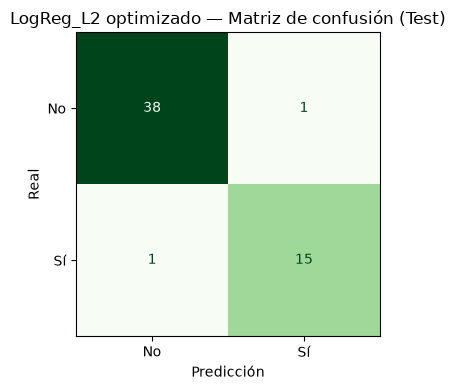

In [128]:
mejor_estimador = busq_random.best_estimator_
y_pred_test_opt = mejor_estimador.predict(X_test)
metricas_opt = evaluate_model(y_test, y_pred_test_opt, mejor_modelo)

final_comparison = pd.DataFrame([
    {'Modelo': f'{mejor_modelo} (hiperparámetros originales)', **test_df.loc[mejor_modelo].to_dict()},
    {'Modelo': f'{mejor_modelo} (optimizado con RandomizedSearchCV)', **metricas_opt},
]).set_index('Modelo').round(3)

display(final_comparison)

fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, y_pred_test_opt)
ConfusionMatrixDisplay(cm, display_labels=['No', 'Sí']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'{mejor_modelo} optimizado — Matriz de confusión (Test)')
plt.tight_layout()
plt.show()





No hay ninguna diferencia. Esto se podría deber a que los parámetros de Scikit.Learn C=1 ya son prácticamente buenos para resolver este problema. 

# FASE 8 - CONCLUSIONES

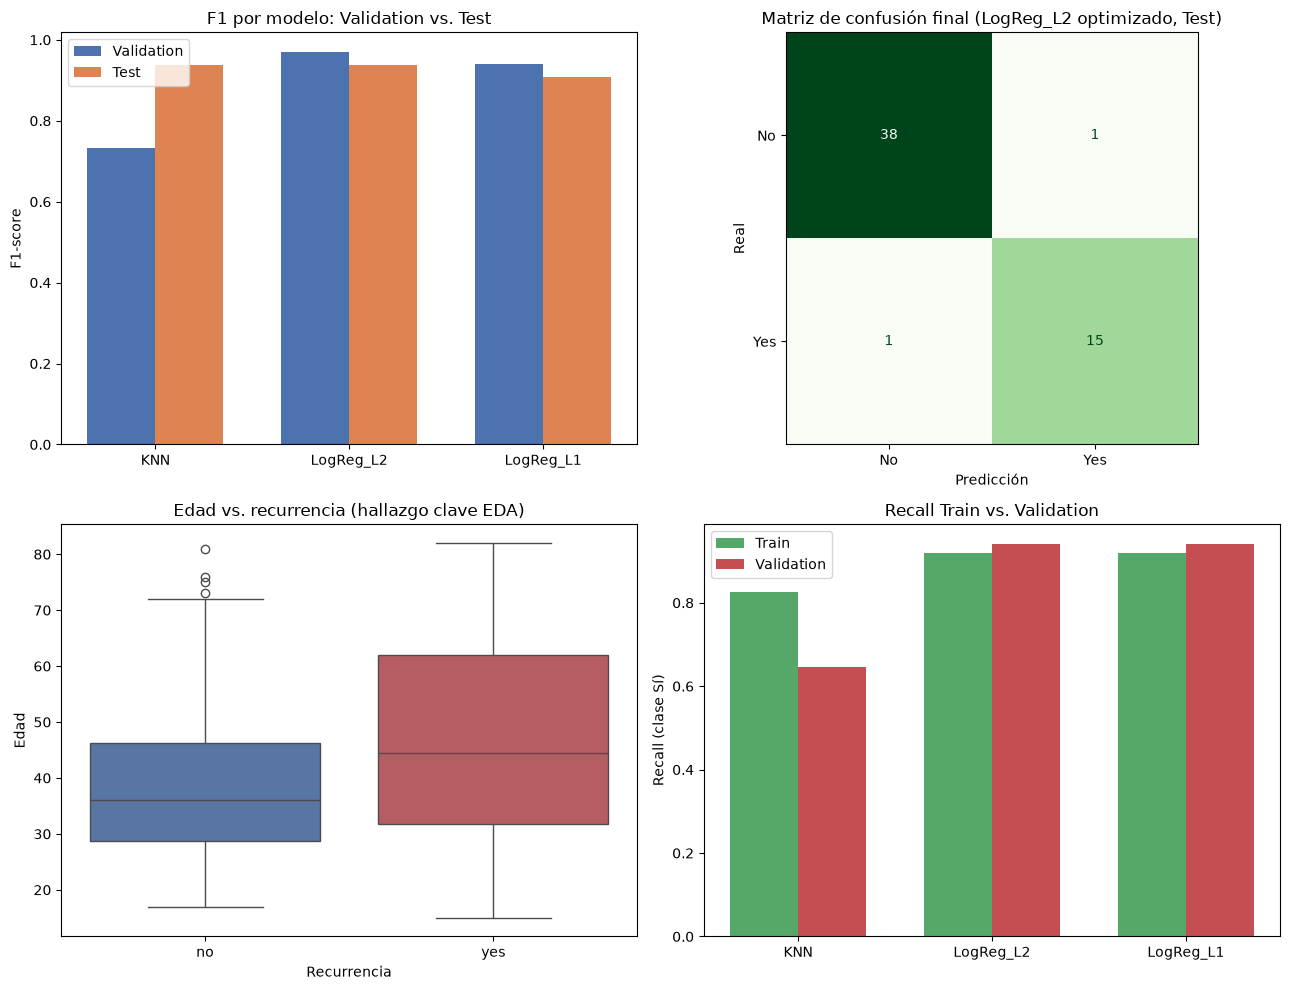

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# comparación por modelo
plot_df = metrics_df.reset_index()
plot_df = plot_df[plot_df['Conjunto'] == 'Validation'][['Modelo', 'F1-Score']].copy()
plot_df['Test_F1'] = [test_df.loc[m, 'F1-Score'].item() for m in plot_df['Modelo']]
x = np.arange(len(plot_df))
w = 0.35
axes[0, 0].bar(x - w/2, plot_df['F1-Score'], width=w, label='Validation', color='#4C72B0')
axes[0, 0].bar(x + w/2, plot_df['Test_F1'], width=w, label='Test', color='#DD8452')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(plot_df['Modelo'])
axes[0, 0].set_ylabel('F1-score')
axes[0, 0].set_title('F1 por modelo: Validation vs. Test')
axes[0, 0].legend()

# matriz de confusión del modelo final optimizado
cm = confusion_matrix(y_test, y_pred_test_opt)
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[0, 1], cmap='Greens', colorbar=False)
axes[0, 1].set_title(f'Matriz de confusión final ({mejor_modelo} optimizado, Test)')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Real')

# distribución de edad por recurrencia (hallazgo clave de EDA)
order = ['no', 'yes'] # Define order for 'recurred' column
sns.boxplot(data=df, x='recurred', y='age', order=order, hue='recurred', legend=False, palette=['#4C72B0', '#C44E52'], ax=axes[1, 0])
axes[1, 0].set_title('Edad vs. recurrencia (hallazgo clave EDA)')
axes[1, 0].set_xlabel('Recurrencia')
axes[1, 0].set_ylabel('Edad')

# accuracy vs Recall en train/val por modelo 
train_recall = metrics_df.xs('Train', level='Conjunto')['Recall']
val_recall = metrics_df.xs('Validation', level='Conjunto')['Recall']
x2 = np.arange(len(models))
axes[1, 1].bar(x2 - w/2, train_recall.values, width=w, label='Train', color='#55A868')
axes[1, 1].bar(x2 + w/2, val_recall.values, width=w, label='Validation', color='#C44E52')
axes[1, 1].set_xticks(x2)
axes[1, 1].set_xticklabels(list(models.keys()))
axes[1, 1].set_ylabel('Recall (clase Sí)')
axes[1, 1].set_title('Recall Train vs. Validation')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Conclusión final:
En conclusión, el modelo ganador termina siendo el de regresión logística L2. 

Tanto del paso a paso de la validación de los modelos, como de las gráficas que tenemos en este punto, se puede observar como KNN sufre bastante con la alta dimensionalidad, notandose el overfitting generado con el conjunto de datos de validación, viendose una caída en la métrica de Recall. Por otro lado, LogReg_L2 logró un buen equilibrio entre sesgo y varianza; debido al parámetro de regularización, los pesos se estabilizaron y el modelo pudo generalizar mucho mejor, dando como resultado final con los datos de test 1 solo falso positivo y 1 falso negativo. Una limitante dentro de este proceso, es la cantidad pequeña de pacientes, que se refleja en el empate de métricas entre el conjunto de datos de validación y el de test. 